<a href="https://colab.research.google.com/github/estefaniaperezpadilla/Estadistica2026B/blob/main/Practica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from numpy.polynomial.polynomial import Polynomial
from scipy.fftpack import fft, ifft

In [ ]:
# Descargar datos de Tesla de los últimos 3 años
df = yf.download(
    "TSLA",
    period="3y",
    interval="1d"
)

# Reiniciar índices
df.reset_index(inplace=True)

# Mostrar primeras filas
df.head()

/tmp/ipykernel_3995/4274244565.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2023-05-15,166.350006,169.759995,164.550003,167.660004,105592500
1,2023-05-16,166.520004,169.520004,164.350006,165.649994,98288800
2,2023-05-17,173.860001,174.500000,167.190002,168.410004,125473600
3,2023-05-18,176.889999,177.059998,172.449997,174.220001,109520300
4,2023-05-19,180.139999,181.949997,176.309998,177.169998,136196700


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        753 non-null    datetime64[ns]
 1   (Close, TSLA)   753 non-null    float64       
 2   (High, TSLA)    753 non-null    float64       
 3   (Low, TSLA)     753 non-null    float64       
 4   (Open, TSLA)    753 non-null    float64       
 5   (Volume, TSLA)  753 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 35.4 KB


In [ ]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
count,753,753.000000,753.000000,753.000000,753.000000,7.530000e+02
mean,2024-11-12 15:29:24.143426304,296.142975,302.183147,289.843878,296.070405,9.821311e+07
min,2023-05-15 00:00:00,142.050003,144.440002,138.800003,140.559998,3.625290e+07
25%,2024-02-13 00:00:00,222.149994,228.220001,217.899994,223.820007,7.155820e+07
50%,2024-11-11 00:00:00,265.279999,272.649994,260.250000,265.290009,9.446420e+07
75%,2025-08-14 00:00:00,380.299988,386.000000,371.869995,376.559998,1.179506e+08
max,2026-05-14 00:00:00,489.880005,498.829987,485.329987,489.880005,2.874998e+08
std,NaN,90.691951,92.378897,89.014971,90.890961,3.497350e+07


In [ ]:
# Ver nombres de columnas
print(df.columns)

# Usar Close como precio ajustado
df = df[["Date", "Close"]]

# Cambiar nombres
df.columns = ["Fecha", "Adj_Close_TSLA"]

df.head()

MultiIndex([(  'Date',     ''),
            ( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


,Fecha,Adj_Close_TSLA
0,2023-05-15,166.350006
1,2023-05-16,166.520004
2,2023-05-17,173.860001
3,2023-05-18,176.889999
4,2023-05-19,180.139999


In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Fecha           753 non-null    datetime64[ns]
 1   Adj_Close_TSLA  753 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.9 KB


In [ ]:
x = df["Fecha"]
y = df["Adj_Close_TSLA"]

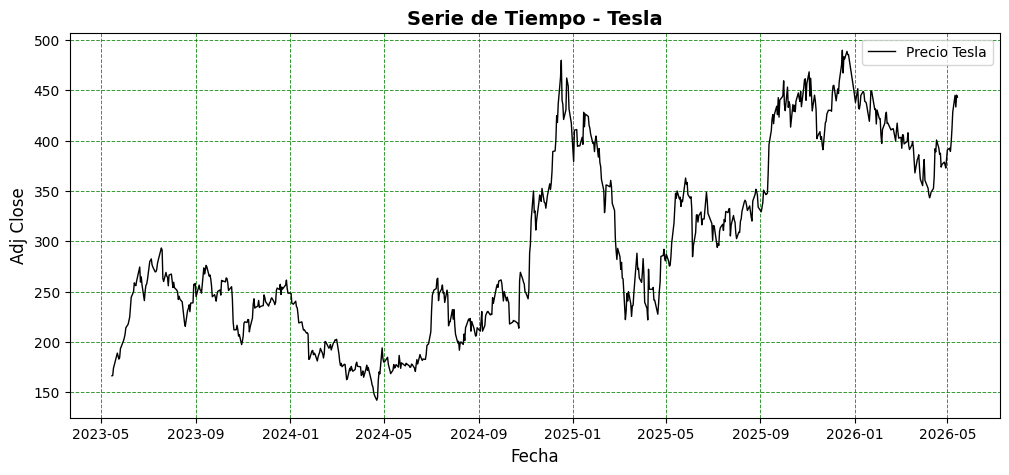

In [ ]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    y,
    color="black",
    linewidth=1,
    label="Precio Tesla"
)

plt.title("Serie de Tiempo - Tesla", fontsize=14, fontweight="bold")

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Adj Close", fontsize=12)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="green"
)

plt.legend()
plt.show()

In [ ]:
# Convertir fechas a timestamp
X = pd.to_datetime(df["Fecha"]).map(pd.Timestamp.timestamp)

# Grado del polinomio
grado = 3

# Modelo polinomial
modelo = Polynomial.fit(X, y, deg=grado)

# Tendencia estimada
df["tendencia_polinomial"] = modelo(X)

# Residuales iniciales
df["ruido_polinomial"] = (
    df["Adj_Close_TSLA"]
    - df["tendencia_polinomial"]
)

df.head()

,Fecha,Adj_Close_TSLA,tendencia_polinomial,ruido_polinomial
0,2023-05-15,166.350006,279.385694,-113.035688
1,2023-05-16,166.520004,278.726301,-112.206297
2,2023-05-17,173.860001,278.070217,-104.210216
3,2023-05-18,176.889999,277.417435,-100.527435
4,2023-05-19,180.139999,276.767951,-96.627951


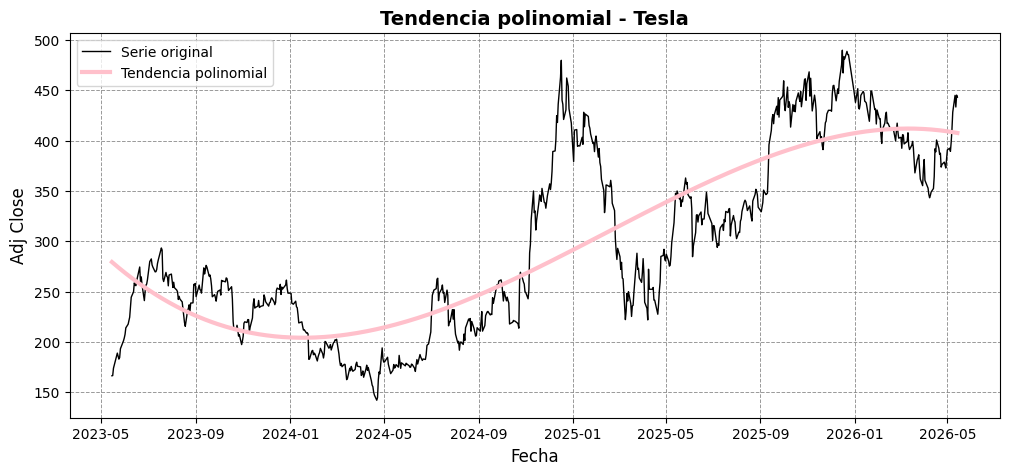

In [ ]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    y,
    color="black",
    linewidth=1,
    label="Serie original"
)

plt.plot(
    x,
    df["tendencia_polinomial"],
    color="pink",
    linewidth=3,
    label="Tendencia polinomial"
)

plt.title("Tendencia polinomial - Tesla", fontsize=14, fontweight="bold")

plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Adj Close", fontsize=12)

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

plt.legend()
plt.show()

In [ ]:
def Transformada_de_Fourier(serie, terminos, un_grafico):

    n = len(serie)

    # Transformada
    transformada_fourier = fft(serie)

    # Frecuencias
    frecuencias = np.fft.fftfreq(n)

    # DataFrame de componentes
    componentes = pd.DataFrame({
        'frecuencia': frecuencias,
        'magnitud': np.abs(transformada_fourier)
    })

    # Eliminar frecuencia 0
    componentes = componentes[componentes["frecuencia"] > 0]

    # Longitud de onda
    componentes["longitud_de_onda"] = (
        1 / componentes["frecuencia"]
    )

    # Ordenar por magnitud
    componentes = componentes.sort_values(
        by="magnitud",
        ascending=False
    )

    # Frecuencias principales
    top_frecuencias = componentes.head(terminos)

    print(top_frecuencias)

    # Reconstrucción
    t = np.arange(n)

    plt.figure(figsize=(12,4))

    componente_temporal_sumado = np.zeros_like(serie)

    for i, row in top_frecuencias.iterrows():

        fourier_component = np.zeros_like(transformada_fourier)

        idx = np.where(
            frecuencias == row["frecuencia"]
        )[0][0]

        fourier_component[idx] = transformada_fourier[idx]
        fourier_component[-idx] = transformada_fourier[-idx]

        componente_temporal = ifft(
            fourier_component
        ).real

        componente_temporal_sumado += componente_temporal

        plt.plot(
            componente_temporal,
            linewidth=1,
            label=f'Onda {1 / row["frecuencia"]:.0f}'
        )

    plt.title("Componentes de Fourier")
    plt.xlabel("Tiempo")
    plt.ylabel("Valor")

    plt.grid()
    plt.legend()

    plt.show()

    if not un_grafico:

        plt.figure(figsize=(12,4))

        plt.plot(
            serie,
            label="Serie Original",
            color="green",
            alpha=0.5
        )

        plt.plot(
            componente_temporal_sumado,
            label="Componente Sumada",
            color="pink"
        )

        plt.legend()

        plt.title("Suma Fourier")
        plt.grid()

        plt.show()

    return componente_temporal_sumado

   frecuencia      magnitud  longitud_de_onda
3    0.003984  17092.489110        251.000000
6    0.007968   8756.900074        125.500000
4    0.005312   7516.879052        188.250000
7    0.009296   6851.439539        107.571429
8    0.010624   6117.578538         94.125000


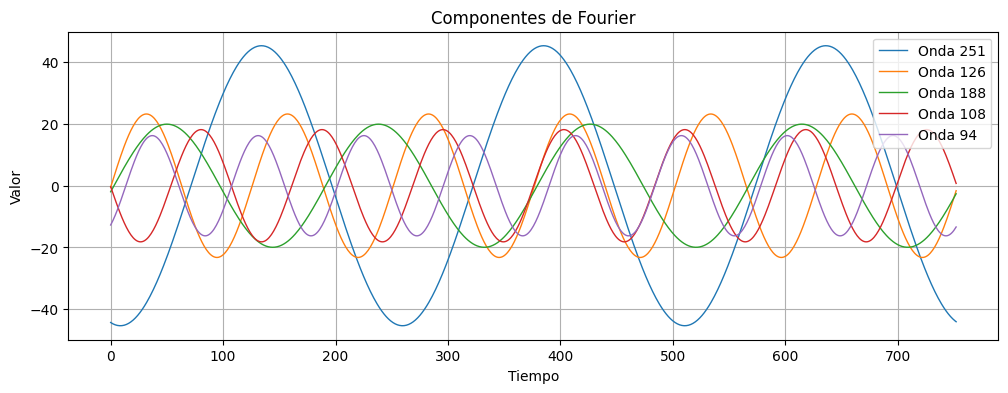

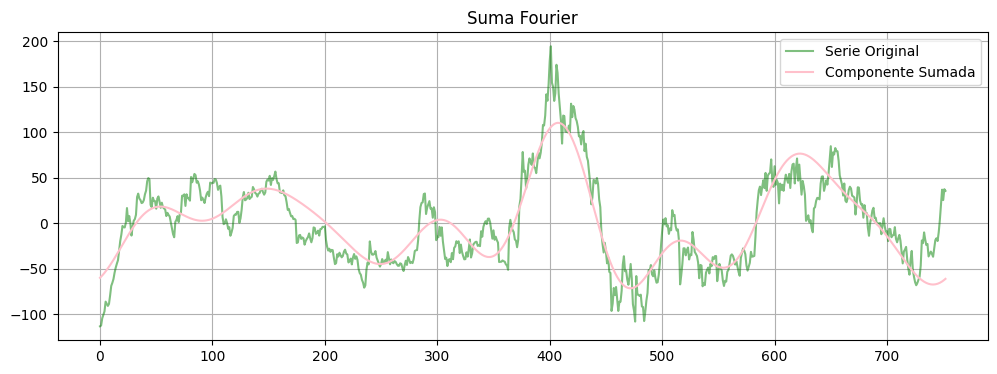

In [ ]:
serie = df["ruido_polinomial"].values

terminos = 5

un_grafico = False

cts = Transformada_de_Fourier(
    serie,
    terminos,
    un_grafico
)

df["estacionalidad_polinomial"] = cts

In [ ]:
df["ruido_final"] = (
    df["Adj_Close_TSLA"]
    - df["tendencia_polinomial"]
    - df["estacionalidad_polinomial"]
)

df.head()

,Fecha,Adj_Close_TSLA,tendencia_polinomial,ruido_polinomial,estacionalidad_polinomial,ruido_final
0,2023-05-15,166.350006,279.385694,-113.035688,-59.816522,-53.219166
1,2023-05-16,166.520004,278.726301,-112.206297,-58.576282,-53.630015
2,2023-05-17,173.860001,278.070217,-104.210216,-57.250149,-46.960067
3,2023-05-18,176.889999,277.417435,-100.527435,-55.841414,-44.686021
4,2023-05-19,180.139999,276.767951,-96.627951,-54.353625,-42.274326


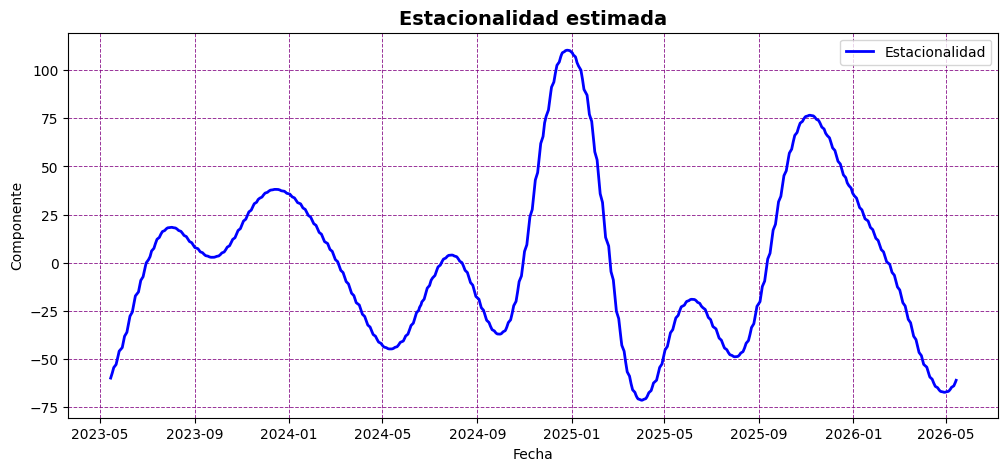

In [ ]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["estacionalidad_polinomial"],
    color="blue",
    linewidth=2,
    label="Estacionalidad"
)

plt.title(
    "Estacionalidad estimada",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Componente")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="purple"
)

plt.legend()

plt.show()

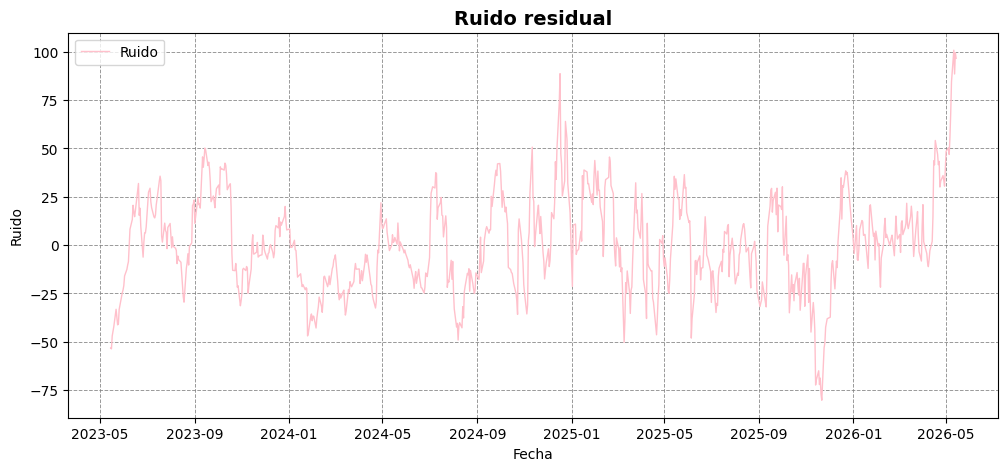

In [ ]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["ruido_final"],
    color="pink",
    linewidth=1,
    label="Ruido"
)

plt.title(
    "Ruido residual",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Ruido")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

plt.legend()

plt.show()

In [ ]:
serie_aproximada = (
    df["tendencia_polinomial"]
    + df["estacionalidad_polinomial"]
    + df["ruido_final"]
)

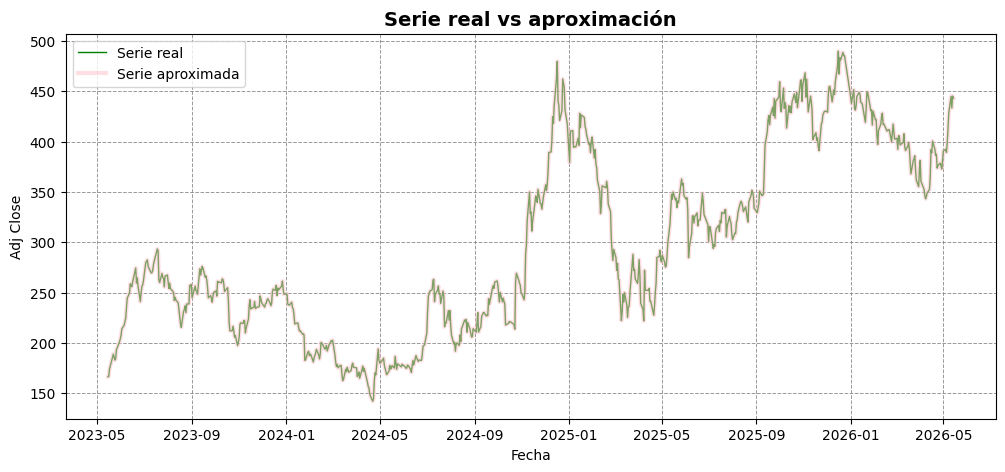

In [ ]:
plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["Adj_Close_TSLA"],
    color="green",
    linewidth=1,
    label="Serie real"
)

plt.plot(
    x,
    serie_aproximada,
    color="pink",
    linewidth=3,
    alpha=0.5,
    label="Serie aproximada"
)

plt.title(
    "Serie real vs aproximación",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Adj Close")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

plt.legend()

plt.show()

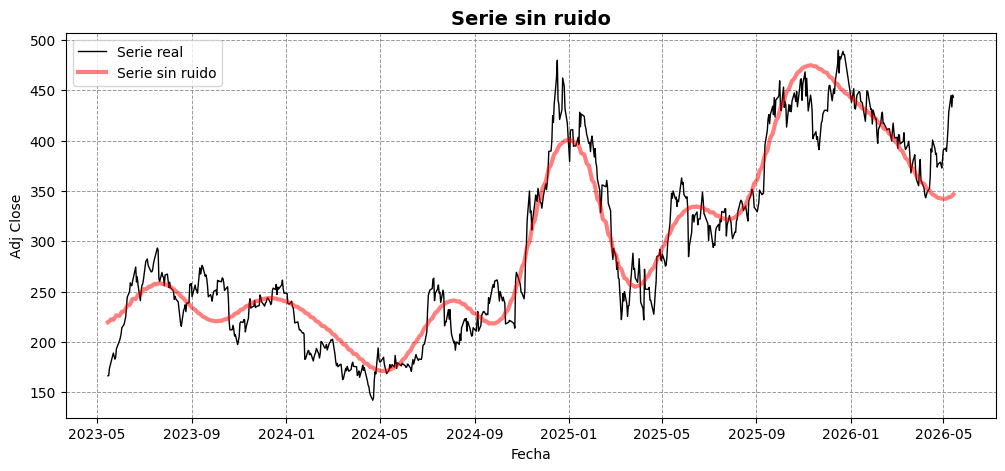

In [ ]:
serie_sin_ruido = (
    df["tendencia_polinomial"]
    + df["estacionalidad_polinomial"]
)

plt.figure(figsize=(12,5), dpi=100)

plt.plot(
    x,
    df["Adj_Close_TSLA"],
    color="black",
    linewidth=1,
    label="Serie real"
)

plt.plot(
    x,
    serie_sin_ruido,
    color="red",
    linewidth=3,
    alpha=0.5,
    label="Serie sin ruido"
)

plt.title(
    "Serie sin ruido",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Adj Close")

plt.grid(
    visible=True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

plt.legend()

plt.show()

**Interpretacion:**
Al analizar la serie de trabajo de las acciones de tesla , puede observar que el comportamiento es agradable y general lo que presenta una tendencia creciente a lo largo de los ultimos tres años , las variaciones son muy importantes y los periodos de alta volatilidad. Esto me hace ver que el periodo de la accion estuvo muy influenciando factores interno de la empresa tesla como condiciones economicas externas. La serie , el precio mstro que los incrementos graduales se aceleraron , esto lo que se puede reflejar que tiene una positiva dentro del mercado hacia la compañia.

La tendencia polinomial exiten caidas temporales , la direccion principal del precio continua siendo ascendente, puede ver que existen caidas temporales pero que se pueden recuperar , la direccion principal del precio continua siendo ascendente, posiblemente debido al aumento en la demanda de los vehiculos electronicos, el desarrollo tecnologico de le empresa y su expansion internacional. Considero que las decisiones estrategicas de la compañia como las innovaciones en baterias, inteligencia artificial y conduccion autonoma , pudieron generar expectativas positivas ene el mercado.

Por ello la estacinalidad detecta mediante la transfomacion de fourier me permitio ver que los patrones repetitivos dentro de ciertos periodos de tiempo, en mi opinion pueden relacionarse con eventos finacieros recurrentes , como los repotes trimestrales de la empresa de las ganacias que puedan tener , los anuncios nuevos delos modelos, cambios en tasas de interes o movimientos generales del sector tecnologico.

Finalmente el ruido residual considero que la mustra movimientos inesperados que no pueden explicarse unicamente con tendencia o estacionalidad , considero que estos cambios repetinos pueden estar asociados con noticias imprevistas , publicaciones en las redes sociales. Esto considero que la serie refleja un activo finaciero altamente muy dinamico , sensible y con muchos factores que sosn muy impostntes.